# Prophet

### Módulo F1 | Previsão de Demanda na Gestão de Planos de Saúde

**Prof. Pedro** &nbsp;·&nbsp; Mestrado e Doutorado em Simulação

---

Nas aulas anteriores vimos os fundamentos e o modelo clássico ARIMA / SARIMA. Chegamos agora ao **Prophet**, criado pela equipe de dados do Facebook (Taylor e Letham, 2018). Ele foi pensado para um público específico: analistas com conhecimento de negócio, mas sem formação avançada em estatística, que precisam prever muitas séries com pouco esforço de ajuste. Os autores chamam isso de previsão com o **analista no loop**.

Para deixar a aula mais dinâmica, trocamos o exemplo. Em vez do volume de ligações, vamos trabalhar com uma série **nova e mais rica**: a **demanda diária por teleconsultas** da operadora, ao longo de **3 anos**. Essa série reúne, de propósito, tudo aquilo em que o Prophet brilha:

- uma **tendência de crescimento** que muda de inclinação no meio do caminho (a adoção da telemedicina acelera);
- uma **sazonalidade semanal** (dias úteis cheios, fim de semana vazio);
- uma **sazonalidade anual** (pico no inverno, com as doenças respiratórias);
- e o efeito dos **feriados nacionais brasileiros**.

**Ao final desta aula você será capaz de:**

1. Entender a equação aditiva do Prophet, termo a termo.
2. Ajustar um Prophet em Python e inspecionar cada componente separadamente.
3. Interpretar changepoints, sazonalidade de Fourier e efeitos de feriados.
4. Avaliar a previsão e ajustar a flexibilidade da tendência.

**Como usar:** execute as células na ordem. Após cada gráfico ou tabela há um box **Lendo o resultado**, interpretando os números ponto a ponto.


## 0. Preparação do ambiente

A célula abaixo instala e importa as bibliotecas. **Atenção:** se o Prophet ainda não estiver instalado no seu ambiente, a primeira execução pode levar alguns minutos. Rode uma vez e aguarde a mensagem de sucesso.


In [10]:
import sys, subprocess

def _garantir(pacotes):
    for nome in pacotes:
        try:
            __import__(nome)
        except ImportError:
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", nome])

_garantir(["numpy", "pandas", "matplotlib", "ipywidgets", "holidays", "prophet"])

import warnings, logging
warnings.filterwarnings("ignore")
logging.getLogger("cmdstanpy").disabled = True     # silencia os logs do backend Stan
logging.getLogger("prophet").setLevel(logging.CRITICAL)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import holidays as feriados_lib
from prophet import Prophet

plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12

print("Ambiente pronto. Prophet e demais bibliotecas carregadas com sucesso.")


Ambiente pronto. Prophet e demais bibliotecas carregadas com sucesso.


## Novo laboratório: demanda diária por teleconsultas

Assim como nos notebooks anteriores, vamos **construir** a série para saber exatamente o que colocamos dentro dela e depois reconhecer cada peça na saída do modelo. A função abaixo monta 3 anos de demanda diária por teleconsultas somando cinco ingredientes:

- um **nível base** com **tendência linear por partes**: cresce devagar no começo e acelera a partir de setembro de 2022, imitando a adoção da telemedicina;
- uma **sazonalidade semanal**: segunda a sexta com alta demanda, fim de semana bem mais baixo;
- uma **sazonalidade anual**: pico no inverno (por volta de julho, no hemisfério sul) e vale no verão;
- o **efeito dos feriados nacionais**: queda acentuada da demanda nesses dias, usando o calendário brasileiro real;
- um **ruído** aleatório.

> **Na prática**, você substituiria a geração por `pd.read_csv('teleconsultas_diarias.csv', parse_dates=['ds'])`, mantendo as colunas no formato que o Prophet exige: `ds` (data) e `y` (valor).


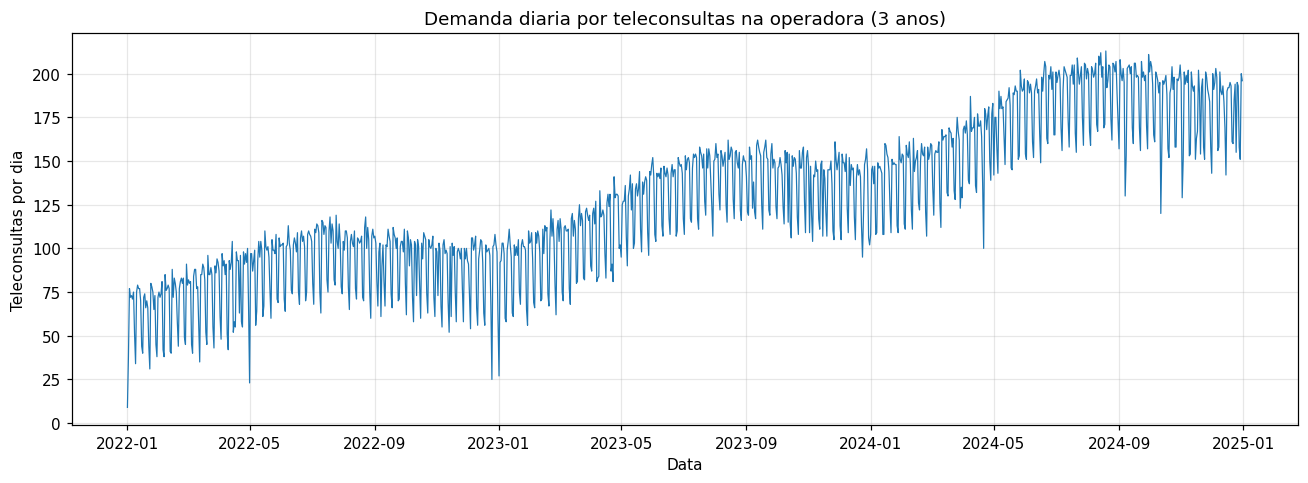

Periodo: 2022-01-01  ate  2024-12-31  (1096 dias)
Media: 128 teleconsultas/dia  |  minimo 9  |  maximo 213


In [11]:
def gerar_teleconsultas(inicio="2022-01-01", fim="2024-12-31", semente=7):
    datas = pd.date_range(inicio, fim, freq="D")
    n = len(datas)
    g = np.random.default_rng(semente)
    t = np.arange(n)

    # Tendencia linear por partes: a inclinacao aumenta apos o changepoint.
    apos_cp = np.asarray(datas >= pd.Timestamp("2022-09-01"), dtype=float)
    nivel = 80 + 0.03 * t + 0.10 * np.cumsum(apos_cp)

    # Sazonalidade semanal (0=seg ... 6=dom):
    peso_semana = np.array([12, 10, 9, 10, 8, -22, -30], dtype=float)[datas.dayofweek.to_numpy()]

    # Sazonalidade anual: pico proximo do dia 196 (meados de julho, inverno).
    peso_ano = 14 * np.cos(2 * np.pi * (datas.dayofyear.to_numpy() - 196) / 365.25)

    # Feriados nacionais brasileiros: forte queda de demanda.
    br = feriados_lib.Brazil(years=range(datas.year.min(), datas.year.max() + 1))
    eh_feriado = np.array([dia.date() in br for dia in datas], dtype=float)
    efeito_feriado = -35 * eh_feriado

    y = nivel + peso_semana + peso_ano + efeito_feriado + g.normal(0, 5, size=n)
    y = np.clip(np.round(y), 0, None)
    return pd.DataFrame({"ds": datas, "y": y})

df = gerar_teleconsultas()

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(df["ds"], df["y"], color="#1f77b4", lw=0.8)
ax.set_title("Demanda diaria por teleconsultas na operadora (3 anos)")
ax.set_xlabel("Data"); ax.set_ylabel("Teleconsultas por dia")
plt.tight_layout(); plt.show()

print(f"Periodo: {df['ds'].min().date()}  ate  {df['ds'].max().date()}  ({len(df)} dias)")
print(f"Media: {df['y'].mean():.0f} teleconsultas/dia  |  minimo {df['y'].min():.0f}  |  maximo {df['y'].max():.0f}")


> **Lendo o gráfico.** São **1096 dias (3 anos)** de demanda, de 2022 a 2024, com média de cerca de **128 teleconsultas por dia**. Vários padrões convivem na mesma figura:
>
> - o nível **cresce de cerca de 80 para cerca de 200** ao longo do período, e a subida fica mais íngreme depois do primeiro semestre (o tal changepoint);
> - a faixa é **grossa e serrilhada** por causa da forte oscilação entre dias úteis e fins de semana;
> - há **ondas anuais**, com os picos coincidindo com os meios de ano (o inverno);
> - e aparecem **quedas pontuais e profundas**, que são os feriados.
>
> Um ARIMA teria dificuldade com essa mistura de tendência que muda, duas sazonalidades e feriados. É exatamente o cenário para o qual o Prophet foi desenhado.


## 4.1 A equação do Prophet, termo a termo

Diferente do ARIMA, que modela a série a partir dos seus próprios valores passados, o Prophet trata a previsão como um problema de **ajuste de curva**: a série observada é a soma de três funções do tempo, mais um erro.

$$ y(t) = g(t) + s(t) + h(t) + \varepsilon_t $$

- $g(t)$, a **tendência**: uma curva de crescimento (linear por partes ou logística) que descreve a trajetória de longo prazo. Linear por partes significa que ela pode **mudar de inclinação** em pontos específicos, os _changepoints_ (Seção 4.2).
- $s(t)$, a **sazonalidade**: modelada por **séries de Fourier** (Seção 4.3), capaz de representar vários ciclos ao mesmo tempo (semanal e anual, por exemplo) de forma suave.
- $h(t)$, os **feriados**: um efeito próprio para cada feriado e para os dias ao redor (Seção 4.4).
- $\varepsilon_t$: o que sobra, tratado como ruído.

A grande vantagem didática é que, depois do ajuste, **cada componente pode ser inspecionado separadamente** com o método `plot_components`. Isso transforma a interpretação do modelo em uma conversa visual com o gestor, em vez de uma explicação de coeficientes. Vamos ajustar o modelo e ver isso na prática.


### Ajustando o modelo (Seção 4.5)

O Prophet exige os dados em duas colunas: **`ds`** (a data) e **`y`** (o valor). A nossa tabela já está nesse formato. Vamos separar as **últimas 8 semanas (56 dias) como teste** e treinar no restante. A configuração ativa a sazonalidade semanal e anual (a diária não faz sentido em dados diários) e adiciona os feriados brasileiros com uma única linha: `add_country_holidays('BR')`.


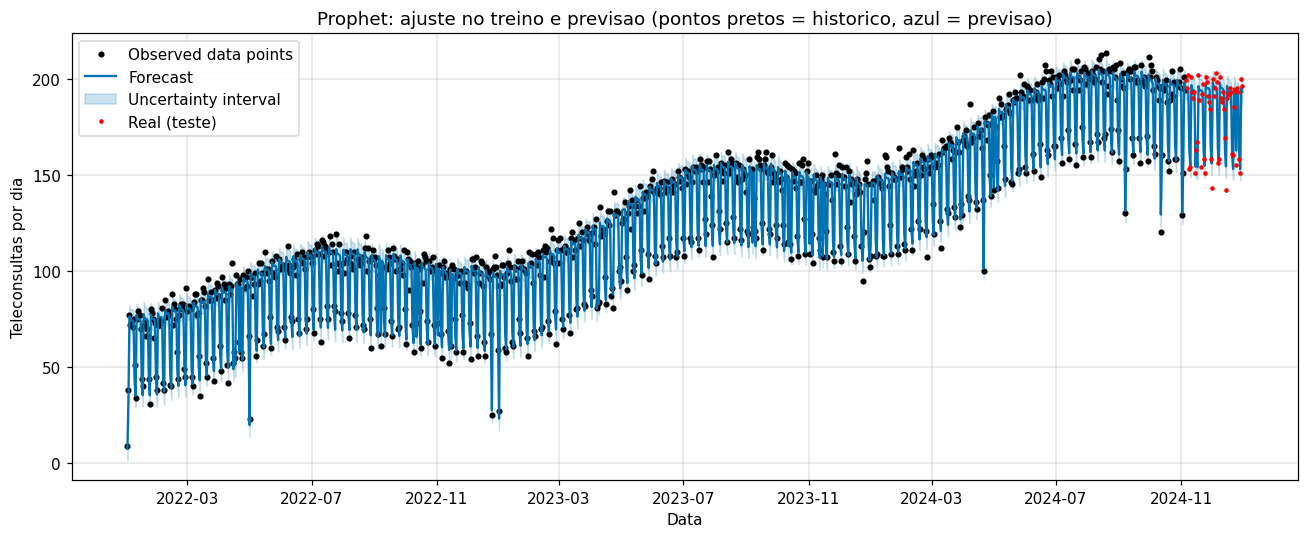

In [12]:
N_TESTE = 56
treino, teste = df.iloc[:-N_TESTE], df.iloc[-N_TESTE:]

modelo = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,   # flexibilidade da tendencia (padrao do Prophet)
)
modelo.add_country_holidays(country_name="BR")
modelo.fit(treino)

# Previsao cobrindo o periodo de teste
futuro = modelo.make_future_dataframe(periods=N_TESTE, freq="D")
previsao = modelo.predict(futuro)

fig = modelo.plot(previsao)
fig.set_size_inches(12, 5)
ax = fig.gca()
ax.plot(teste["ds"], teste["y"], "r.", ms=4, label="Real (teste)")
ax.set_title("Prophet: ajuste no treino e previsao (pontos pretos = historico, azul = previsao)")
ax.set_xlabel("Data"); ax.set_ylabel("Teleconsultas por dia"); ax.legend(loc="upper left")
plt.tight_layout(); plt.show()


> **Lendo o gráfico.** Este é o gráfico padrão do Prophet. Os **pontos pretos** são os dados históricos de treino; a **linha azul** é o ajuste e a previsão do modelo; a **faixa azul clara** é o intervalo de incerteza. Os **pontos vermelhos** que acrescentamos são os valores reais do período de teste, que o modelo não viu.
>
> Repare em três coisas: a linha azul **acompanha a subida de longo prazo**, ela **reproduz o serrilhado semanal** dia após dia, e, no trecho final, os pontos vermelhos caem **em cima da faixa de previsão**. Ou seja, a previsão para 8 semanas à frente ficou coerente com o que de fato aconteceu. A seguir, abrimos o modelo para ver de onde vem cada parte dessa curva.


### Abrindo a caixa: os componentes do modelo

O método `plot_components` mostra, um por um, os termos da equação $y(t) = g(t) + s(t) + h(t)$. É aqui que o Prophet se torna uma ferramenta de conversa com a gestão.


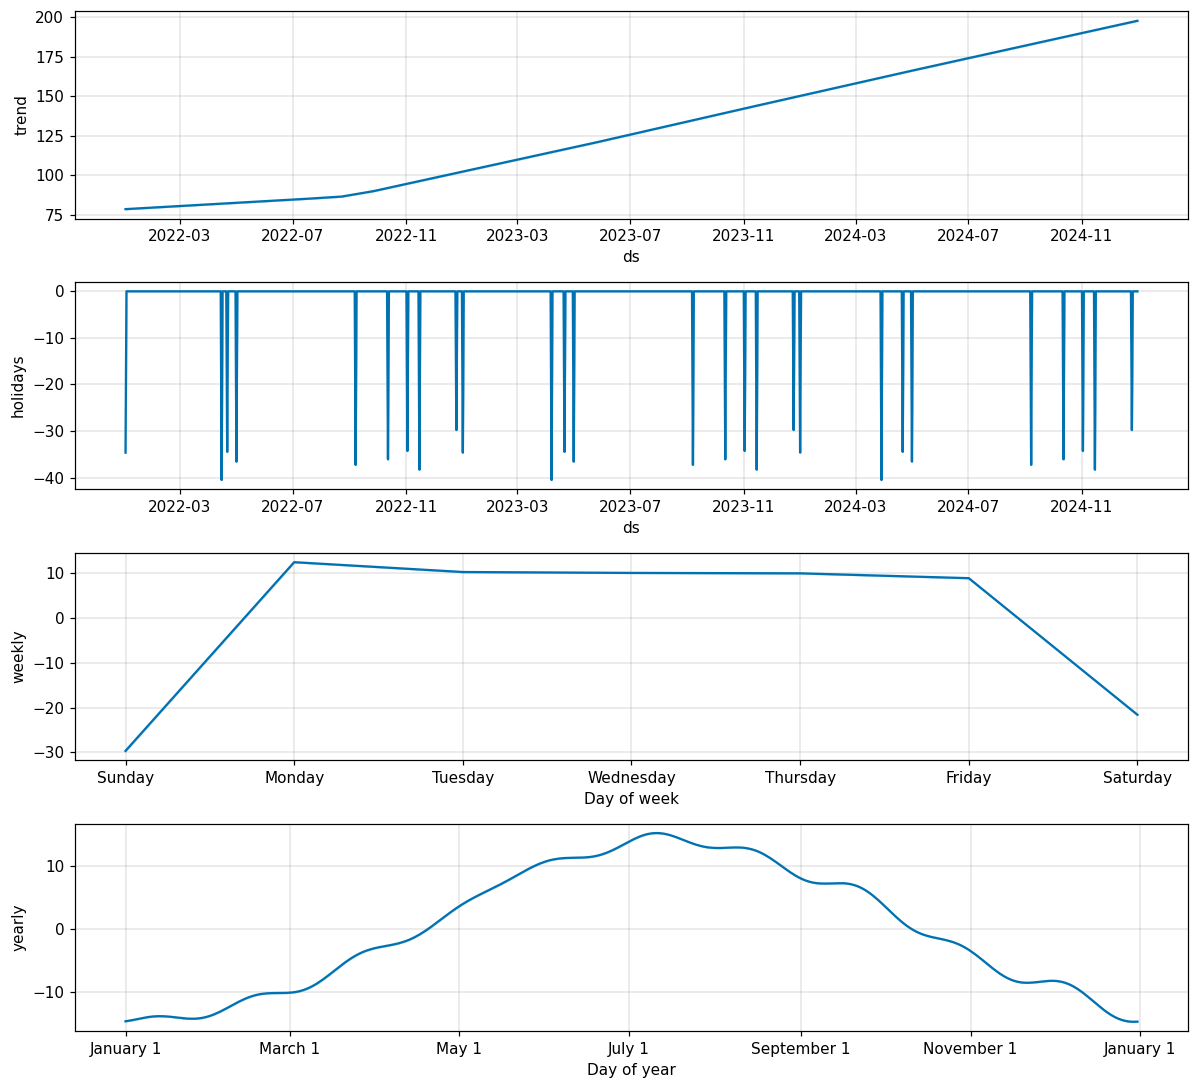

In [13]:
fig = modelo.plot_components(previsao)
fig.set_size_inches(11, 10)
plt.tight_layout(); plt.show()


> **Lendo os painéis.** De cima para baixo, cada painel é um termo da equação:
>
> - **trend** ($g(t)$): a tendência de longo prazo, uma linha que sobe e **muda de inclinação** ao longo do tempo, ficando mais íngreme depois do segundo semestre de 2022. É o crescimento da adoção da telemedicina isolado de todo o resto.
> - **holidays** ($h(t)$): quedas pontuais para baixo, cada uma correspondendo a um feriado nacional. O efeito estimado gira em torno de **-35 a -40 teleconsultas** no dia do feriado.
> - **weekly** ($s(t)$ semanal): a forma da semana, com os **dias úteis bem acima de zero e o fim de semana bem abaixo** (a diferença entre segunda e domingo passa de 40 teleconsultas).
> - **yearly** ($s(t)$ anual): a onda do ano, com **pico por volta de julho** (inverno) e **vale no começo do ano** (verão).
>
> Somando os quatro painéis, mais o ruído, reconstruímos a série original. Essa decomposição transparente é a marca registrada do Prophet.


## 4.2 Changepoints: como o Prophet aprende mudanças de tendência

Uma mudança na política de agendamento, uma campanha de adesão ou o próprio crescimento da carteira podem alterar de forma **permanente** o nível de demanda. O Prophet lida com isso deixando a inclinação da tendência mudar em pontos específicos, os **changepoints**. Por padrão, ele espalha changepoints candidatos ao longo dos primeiros 80% da série e usa uma **penalização** para manter apenas os que realmente importam, evitando o overfitting. O gráfico abaixo marca, em vermelho tracejado, os changepoints com efeito relevante.


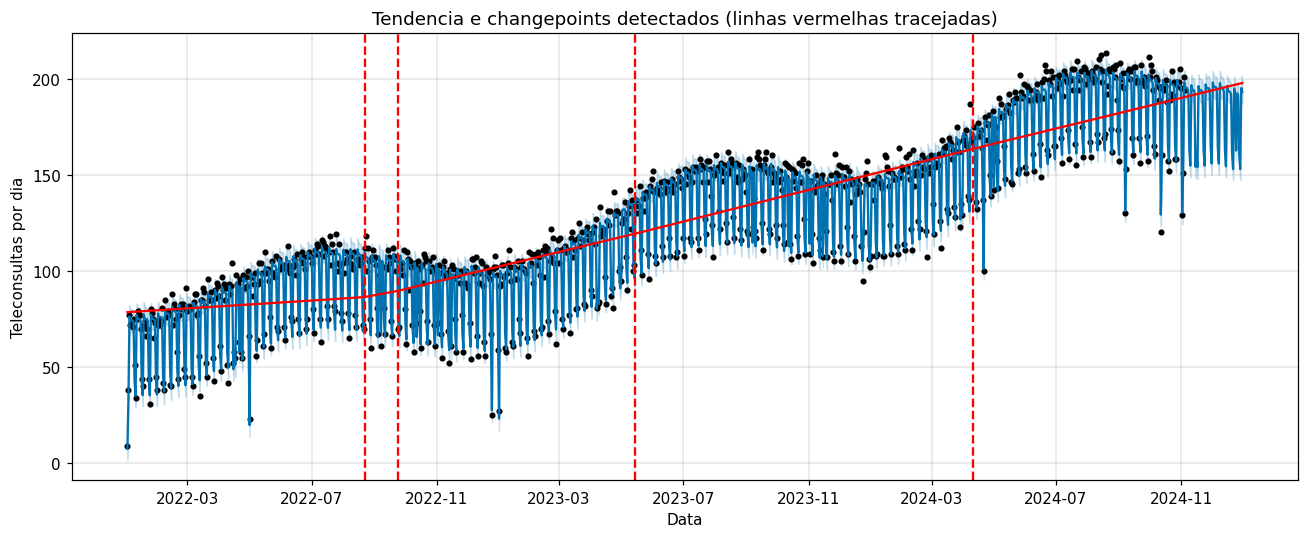

Changepoints candidatos avaliados: 25
Changepoints com mudanca de inclinacao relevante: 4


In [14]:
from prophet.plot import add_changepoints_to_plot

fig = modelo.plot(previsao)
fig.set_size_inches(12, 5)
add_changepoints_to_plot(fig.gca(), modelo, previsao)
fig.gca().set_title("Tendencia e changepoints detectados (linhas vermelhas tracejadas)")
fig.gca().set_xlabel("Data"); fig.gca().set_ylabel("Teleconsultas por dia")
plt.tight_layout(); plt.show()

import numpy as np
deltas = np.array(modelo.params["delta"]).mean(axis=0)
relevantes = int((np.abs(deltas) > 0.01).sum())
print(f"Changepoints candidatos avaliados: {len(modelo.changepoints)}")
print(f"Changepoints com mudanca de inclinacao relevante: {relevantes}")


> **Lendo o gráfico.** A linha vermelha contínua é a tendência $g(t)$ e as linhas **vermelhas tracejadas** marcam os changepoints selecionados. Dos **25 pontos candidatos** que o Prophet avaliou, apenas cerca de **3 tiveram mudança de inclinação relevante**, e o principal deles fica perto do segundo semestre de 2022, exatamente onde plantamos a aceleração da demanda.
>
> A lição prática: o Prophet **não** cria um changepoint em cada solavanco da série; a penalização faz com que ele use poucos pontos, só onde a virada de tendência é sustentada. É isso que o protege de aprender ruído como se fosse sinal.


## 4.3 Sazonalidade via séries de Fourier

Uma **série de Fourier** representa qualquer padrão periódico como a soma de várias ondas de seno e cosseno. Em vez de tratar a sazonalidade anual como 365 valores independentes, o Prophet a representa com **poucas ondas**, o que produz uma curva **suave** e que generaliza melhor. Quanto mais termos de Fourier, mais flexível (e mais sujeita a overfitting) fica a curva. Vamos isolar a sazonalidade anual aprendida e olhar a sua forma.


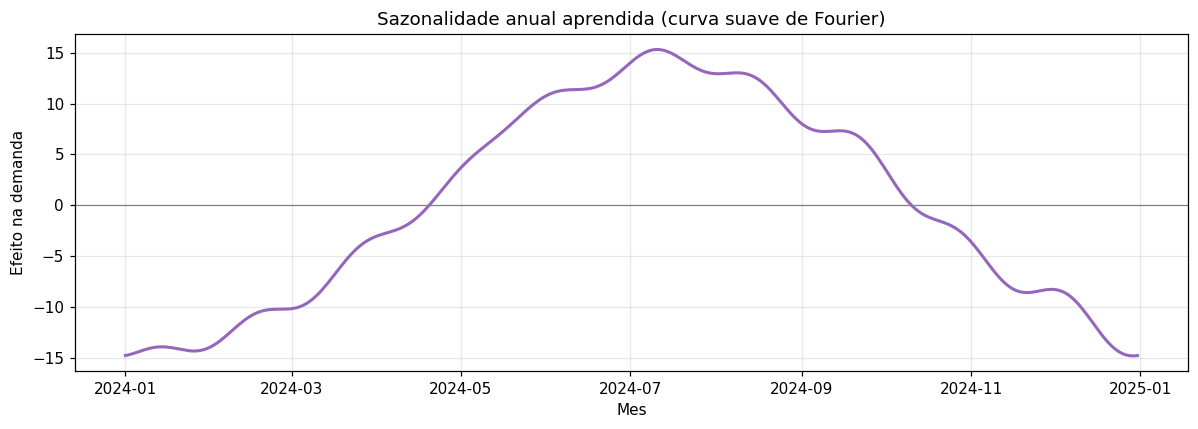

Pico anual: mes 7 (efeito +14)
Vale anual: mes 1 (efeito -14)


In [15]:
um_ano = previsao[previsao["ds"] >= "2024-01-01"][["ds", "yearly"]].copy()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(um_ano["ds"], um_ano["yearly"], color="#9467bd", lw=2)
ax.axhline(0, color="gray", lw=0.8)
ax.set_title("Sazonalidade anual aprendida (curva suave de Fourier)")
ax.set_xlabel("Mes"); ax.set_ylabel("Efeito na demanda")
plt.tight_layout(); plt.show()

por_mes = previsao.assign(mes=previsao["ds"].dt.month).groupby("mes")["yearly"].mean()
print(f"Pico anual: mes {por_mes.idxmax()} (efeito +{por_mes.max():.0f})")
print(f"Vale anual: mes {por_mes.idxmin()} (efeito {por_mes.min():.0f})")


> **Lendo o gráfico.** A curva roxa é a sazonalidade anual $s(t)$ que o Prophet aprendeu, e ela é **suave**, sem serrilhado, justamente porque é a soma de poucas ondas de Fourier. O ponto mais alto fica em torno de **julho (efeito de cerca de +14)** e o mais baixo em **janeiro (cerca de -14)**, uma amplitude de quase 30 teleconsultas entre o auge do inverno e o fundo do verão.
>
> Para a operadora, essa curva antecipa a pressão sazonal: dá para começar a reforçar a rede de teleconsulta antes do pico de inverno, e não durante ele.


## 4.4 Feriados brasileiros

Uma grande conveniência do Prophet para o contexto nacional é o suporte a **calendários de feriados pré-cadastrados**. Com `add_country_holidays(country_name='BR')`, o modelo incorpora automaticamente os feriados nacionais, inclusive os móveis como Carnaval e Corpus Christi, sem nenhum mapeamento manual. Cada feriado ganha o seu próprio efeito estimado. A tabela abaixo mostra os que mais reduzem a demanda.


In [16]:
nomes_feriados = list(modelo.train_holiday_names)
efeitos = {}
for nome in nomes_feriados:
    if nome in previsao.columns:
        valores = previsao[nome][previsao[nome] != 0]
        if len(valores):
            efeitos[nome] = valores.mean()

efeitos = pd.Series(efeitos).sort_values()
print("Efeito estimado por feriado (teleconsultas acima/abaixo do normal):")
print(efeitos.round(1).to_string())


Efeito estimado por feriado (teleconsultas acima/abaixo do normal):
Good Friday                    -40.5
Republic Proclamation Day      -38.3
Independence Day               -37.3
Worker's Day                   -36.6
Our Lady of Aparecida          -36.1
Universal Fraternization Day   -34.6
Tiradentes' Day                -34.5
All Souls' Day                 -34.3
Christmas Day                  -29.8


> **Lendo a tabela.** Cada linha é um feriado nacional e o seu **efeito médio estimado** sobre a demanda. Todos são fortemente **negativos**, em torno de **-35 a -40 teleconsultas**, com a Sexta-feira Santa liderando as quedas (cerca de **-40**). Isso bate com o que construímos na série (uma queda de 35, mais o ruído).
>
> O ponto importante não é o número em si, e sim o fato de o Prophet **isolar cada feriado como um efeito próprio e interpretável**. Na prática, isso evita que o modelo confunda a queda de um feriado com uma queda de tendência, e permite prever com antecedência os vales de demanda no calendário.


## Avaliação: o quanto acertamos, e o valor dos feriados

Números na mão. Vamos medir o erro no período de teste com MAE, RMSE e MAPE (Seção 12) e, de quebra, comparar o modelo completo com uma versão **sem** o componente de feriados, para quantificar o que eles agregam.


In [17]:
def metricas(y_real, y_prev):
    y_real = np.asarray(y_real, dtype=float); y_prev = np.asarray(y_prev, dtype=float)
    erro = y_real - y_prev
    return (np.mean(np.abs(erro)),
            np.sqrt(np.mean(erro ** 2)),
            np.mean(np.abs(erro / y_real)) * 100)

# Modelo sem feriados, para comparar
modelo_sem = Prophet(weekly_seasonality=True, yearly_seasonality=True,
                     daily_seasonality=False, changepoint_prior_scale=0.05)
modelo_sem.fit(treino)
prev_sem = modelo_sem.predict(futuro)

comp_completo = teste.merge(previsao[["ds", "yhat"]], on="ds")
comp_sem = teste.merge(prev_sem[["ds", "yhat"]], on="ds")

tabela = pd.DataFrame(
    [("Prophet COM feriados", *metricas(comp_completo["y"], comp_completo["yhat"])),
     ("Prophet SEM feriados", *metricas(comp_sem["y"], comp_sem["yhat"]))],
    columns=["Modelo", "MAE", "RMSE", "MAPE (%)"],
)
print(tabela.round(2).to_string(index=False))


              Modelo  MAE  RMSE  MAPE (%)
Prophet COM feriados 5.20  7.71      3.03
Prophet SEM feriados 6.86 10.43      4.03


> **Lendo a tabela.** O modelo **completo** erra, em média, cerca de **5 teleconsultas por dia** (MAE) no período de teste, o que dá um **MAPE de cerca de 3%**: em uma demanda que ronda 200 teleconsultas/dia no fim da série, errar 5 é muito pouco.
>
> A comparação com a versão **sem feriados** mostra o valor daquele único componente: o MAPE sobe de cerca de **3,0% para cerca de 4,0%**. Ou seja, adicionar o calendário de feriados, com uma linha de código, reduziu o erro relativo em torno de um ponto percentual, concentrado justamente nos dias que mais atrapalham o planejamento.


## Laboratório interativo: a flexibilidade da tendência

O hiperparâmetro mais importante do Prophet é o **`changepoint_prior_scale`**, que controla o quanto a tendência pode se dobrar:

- **valores baixos** (por exemplo 0,01) deixam a tendência **rígida**, quase uma reta: o modelo pode **subajustar** (ignorar viradas reais);
- **valores altos** (por exemplo 0,5) deixam a tendência **muito flexível**: o modelo pode **sobreajustar**, seguindo o ruído.

Mova o controle e veja a tendência mudar de caráter. O título mostra o MAPE no teste a cada escolha. O valor padrão do Prophet é 0,05.


In [ ]:
from prophet.plot import add_changepoints_to_plot

try:
    from ipywidgets import interact, SelectionSlider
    _INTERATIVO = True
except ImportError:
    _INTERATIVO = False

def laboratorio_flexibilidade(changepoint_prior_scale=0.05):
    m = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False,
                changepoint_prior_scale=changepoint_prior_scale)
    m.add_country_holidays(country_name="BR")
    m.fit(treino)
    fc = m.predict(futuro)
    comp = teste.merge(fc[["ds", "yhat"]], on="ds")
    _, _, mape = metricas(comp["y"], comp["yhat"])

    fig = m.plot(fc)
    fig.set_size_inches(12, 4.5)
    add_changepoints_to_plot(fig.gca(), m, fc)
    fig.gca().plot(teste["ds"], teste["y"], "r.", ms=4)
    fig.gca().set_title(f"changepoint_prior_scale = {changepoint_prior_scale}   |   MAPE no teste = {mape:.1f}%")
    fig.gca().set_xlabel("Data"); fig.gca().set_ylabel("Teleconsultas por dia")
    plt.tight_layout(); plt.show()

if _INTERATIVO:
    interact(laboratorio_flexibilidade,
             changepoint_prior_scale=SelectionSlider(
                 options=[0.01, 0.05, 0.1, 0.3, 0.5], value=0.05,
                 description="flexibilidade"))
else:
    print("ipywidgets indisponivel; exibindo rigido (0.01) e flexivel (0.5).")
    laboratorio_flexibilidade(0.01)
    laboratorio_flexibilidade(0.5)


interactive(children=(SelectionSlider(description='flexibilidade', index=1, options=(0.01, 0.05, 0.1, 0.3, 0.5…

> **O que observar.** No valor padrão (**0,05**), a tendência tem algumas dobras suaves e o MAPE fica baixo. Puxe o controle para **0,01** e veja a tendência virar quase uma reta rígida: ela perde a aceleração de 2022 e o erro tende a subir (subajuste). Puxe para **0,5** e a tendência fica **cheia de curvas**, tentando seguir cada oscilação: o modelo passa a capturar ruído, o que costuma piorar a previsão fora da amostra (sobreajuste). O ponto de equilíbrio é justamente o que o valor padrão busca oferecer.


## Síntese, limitações e próximo passo

O Prophet entregou, num único modelo e com pouquíssimo ajuste, o que o SARIMA fazia com esforço: capturou a **tendência com virada de inclinação**, **duas sazonalidades ao mesmo tempo** (semanal e anual) e o **efeito dos feriados**, tudo de forma **inspecionável** painel a painel. Para a gestão da operadora, essa transparência vale ouro: cada componente vira um argumento visual sobre a demanda.

**Quando usar o Prophet na operadora:** séries diárias com múltiplas sazonalidades e forte influência de calendário, como teleconsultas, volume de autorizações prévias ou acessos ao aplicativo do beneficiário. É rápido de ajustar, robusto a dados faltantes e fácil de explicar.

**Limitações que apontam para os próximos módulos:**

- O Prophet é um modelo **aditivo e univariado por natureza**: ele não aprende, de forma nativa, interações ricas entre muitas variáveis externas.
- Quando o problema tem **muitos fatores explicativos** (clima, campanhas, indicadores epidemiológicos, características do beneficiário), modelos de **árvores e gradient boosting** (XGBoost, LightGBM) e **redes neurais** (LSTM) tendem a levar vantagem, capturando relações não lineares que o Prophet não modela.

É esse o caminho das próximas seções: sair dos modelos que olham apenas o tempo e entrar nos que aprendem a partir de muitas variáveis ao mesmo tempo.

---

**Referências**

- Taylor, S. J.; Letham, B. (2018). Forecasting at Scale. _The American Statistician_.
- Hyndman, R. J.; Athanasopoulos, G. (2021). _Forecasting: Principles and Practice_, 3ª edição.
